# Feature Experiment Lab

This notebook is the main experiment lab for feature testing. It keeps one shared base experiment, a list of experiment variants, and one unified comparison flow so the same analysis logic is not duplicated for every idea.


## 1. Setup

In [12]:
import json
from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

def find_task_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for candidate in candidates:
        if candidate.name == "task-house-prices" and (candidate / "src").exists():
            return candidate
        nested = candidate / "courses/01-machine-learning-with-python/tasks/task-house-prices"
        if nested.exists() and (nested / "src").exists():
            return nested
    fallback = Path("/Users/maksymponarenko/Documents/ai-engineering-kaggle-portfolio/courses/01-machine-learning-with-python/tasks/task-house-prices")
    if fallback.exists() and (fallback / "src").exists():
        return fallback
    raise FileNotFoundError("Could not locate the task-house-prices project root.")

TASK_DIR = find_task_root()
SRC_DIR = TASK_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Task directory:", TASK_DIR)
print("Source directory:", SRC_DIR)

from config import CONFIG
from evaluate import compare_models, compute_permutation_importance
from experiment_config import ExperimentConfig, resolve_columns, resolve_derived_features
from experiment_runner import apply_feature_builders, run_experiment
from feature_analysis import categorical_cardinality_table, missingness_table, skewness_table
from feature_builders import FEATURE_BUILDERS
from processing_config import CategoricalProcessingConfig, NumericProcessingConfig, OrdinalProcessingConfig
import reporting
from reporting import build_after_processing_preview, build_full_transformed_dataframe
from utils import ensure_directories, load_datasets


Task directory: /Users/maksymponomarenko/Documents/ai-engineering-kaggle-portfolio/courses/01-machine-learning-with-python/tasks/task-house-prices
Source directory: /Users/maksymponomarenko/Documents/ai-engineering-kaggle-portfolio/courses/01-machine-learning-with-python/tasks/task-house-prices/src


## 2. Notebook controls

In [13]:
SAVE_EXPERIMENT_OUTPUTS = False
RUN_MODEL_COMPARISON = True
RUN_PERMUTATION_IMPORTANCE = True
PREVIEW_MODEL_NAME = "random_forest"
AFTER_PREVIEW_ROWS = 20
SELECTED_EXPERIMENT_KEY = "baseline_no_new_interaction"
MODEL_NAMES = ["linear_regression", "ridge", "lasso", "random_forest"]


## 3. Base experiment and experiment variants

In [ ]:
base_experiment = ExperimentConfig(
    name="garage_interaction_base",
    description="Shared base for garage interaction experiments built on top of the previous stronger garage-focused setup.",
    feature_groups=["numeric_core", "ordinal_core", "categorical_core"],
    derived_feature_groups=["engineered_core"],
    add_columns=["TotalSF", "HouseAge", "TotalBathrooms"],
    drop_columns=["TotalBsmtSF", "1stFlrSF", "2ndFlrSF"],
    numeric_processing_overrides={
        "LotArea": NumericProcessingConfig(impute_strategy="median", transform="log1p", scale="standard"),
        "GrLivArea": NumericProcessingConfig(impute_strategy="median", transform="log1p", scale="standard"),
        "HouseAge": NumericProcessingConfig(impute_strategy="median", transform="none", scale="standard"),
        "TotalSF": NumericProcessingConfig(impute_strategy="median", transform="none", scale="quantile"),
        "GarageArea": NumericProcessingConfig(impute_strategy="constant", fill_value=0, transform="none", scale="quantile"),

    },
    categorical_processing_overrides={
        "Neighborhood": CategoricalProcessingConfig(impute_strategy="most_frequent", encoding="onehot", min_frequency=0.01),
    },
    ordinal_processing_overrides={
        "KitchenQual": OrdinalProcessingConfig(impute_strategy="constant", fill_value="__MISSING__", encoding="explicit_ordinal"),
    },
)

def garage_area_like_processing():
    return NumericProcessingConfig(
        impute_strategy="median",
        transform="none",
        scale="quantile",
    )

def load_saved_experiment_definition(relative_path):
    definition_path = TASK_DIR / relative_path
    if not definition_path.exists():
        raise FileNotFoundError(f"Saved experiment definition not found: {definition_path}")
    return json.loads(definition_path.read_text(encoding="utf-8"))

def load_saved_processing_summary(relative_path):
    summary_path = TASK_DIR / relative_path
    if not summary_path.exists():
        return pd.DataFrame()
    return pd.read_csv(summary_path)

def combine_selected_features(definition):
    features = []
    for key in ["selected_features", "selected_numeric_features", "selected_categorical_features", "selected_ordinal_features"]:
        for feature in definition.get(key, []):
            if feature not in features:
                features.append(feature)
    return features

def build_numeric_overrides_from_definition(definition):
    return {
        column: NumericProcessingConfig(**settings)
        for column, settings in definition.get("numeric_processing_overrides", {}).items()
    }

def build_categorical_overrides_from_definition(definition):
    return {
        column: CategoricalProcessingConfig(**settings)
        for column, settings in definition.get("categorical_processing_overrides", {}).items()
    }

def build_ordinal_overrides_from_definition(definition):
    return {
        column: OrdinalProcessingConfig(**settings)
        for column, settings in definition.get("ordinal_processing_overrides", {}).items()
    }

def build_overrides_from_processing_summary(summary_df):
    numeric_overrides = {}
    categorical_overrides = {}
    ordinal_overrides = {}
    if summary_df.empty:
        return numeric_overrides, categorical_overrides, ordinal_overrides
    for row in summary_df.to_dict(orient="records"):
        feature = row.get("feature")
        feature_type = row.get("feature_type")
        if not feature:
            continue
        if feature_type == "numeric":
            numeric_overrides[feature] = NumericProcessingConfig(
                impute_strategy=row.get("impute_strategy", "median"),
                fill_value=row.get("fill_value") if pd.notna(row.get("fill_value")) else None,
                transform=row.get("transform", "none"),
                scale=row.get("scale", "none"),
            )
        elif feature_type == "categorical":
            min_frequency = row.get("min_frequency")
            categorical_overrides[feature] = CategoricalProcessingConfig(
                impute_strategy=row.get("impute_strategy", "most_frequent"),
                fill_value=row.get("fill_value") if pd.notna(row.get("fill_value")) else None,
                encoding=row.get("encoding", "onehot"),
                min_frequency=None if pd.isna(min_frequency) else min_frequency,
            )
        elif feature_type == "ordinal":
            ordinal_overrides[feature] = OrdinalProcessingConfig(
                impute_strategy=row.get("impute_strategy", "constant"),
                fill_value=row.get("fill_value", "__MISSING__") if pd.notna(row.get("fill_value")) else "__MISSING__",
                encoding=row.get("encoding", "explicit_ordinal"),
            )
    return numeric_overrides, categorical_overrides, ordinal_overrides

EXPERIMENT_VARIANTS = [
    {
        "key": "baseline_no_new_interaction",
        "name": "baseline_no_new_interaction",
        "description": "Baseline variant with the previous base feature set and no new garage interaction feature.",
        "add_columns": [],
    },
    {
        "key": "replay_saved_totalsf_experiment",
        "name": "replay_saved_totalsf_experiment",
        "description": "Replay the previously saved TotalSF-focused experiment using the saved effective processing summary when available.",
        "source_experiment_definition": "outputs/experiments/1 - TotalSF-focused_experiment: transform=none, scale=quantile/experiment_definition.json",
        "source_processing_summary": "outputs/experiments/1 - TotalSF-focused_experiment: transform=none, scale=quantile/reports/column_processing_summary.csv",
    },
    {
        "key": "garage_qual_x_garage_area",
        "name": "garage_qual_x_garage_area",
        "description": "Add GarageQual mapped ordinal score multiplied by GarageArea.",
        "add_columns": ["GarageQual_x_GarageArea"],
        "numeric_processing_overrides": {"GarageQual_x_GarageArea": garage_area_like_processing()},
    },
    {
        "key": "garage_qual_x_garage_cars",
        "name": "garage_qual_x_garage_cars",
        "description": "Add GarageQual mapped ordinal score multiplied by GarageCars.",
        "add_columns": ["GarageQual_x_GarageCars"],
        "numeric_processing_overrides": {"GarageQual_x_GarageCars": garage_area_like_processing()},
    },
    {
        "key": "garage_cond_x_garage_area",
        "name": "garage_cond_x_garage_area",
        "description": "Add GarageCond mapped ordinal score multiplied by GarageArea.",
        "add_columns": ["GarageCond_x_GarageArea"],
        "numeric_processing_overrides": {"GarageCond_x_GarageArea": garage_area_like_processing()},
    },
    {
        "key": "garage_cond_x_garage_cars",
        "name": "garage_cond_x_garage_cars",
        "description": "Add GarageCond mapped ordinal score multiplied by GarageCars.",
        "add_columns": ["GarageCond_x_GarageCars"],
        "numeric_processing_overrides": {"GarageCond_x_GarageCars": garage_area_like_processing()},
    },
    {
        "key": "garage_qual_x_garage_cond_x_garage_area",
        "name": "garage_qual_x_garage_cond_x_garage_area",
        "description": "Add GarageQual times GarageCond times GarageArea.",
        "add_columns": ["GarageQual_x_GarageCond_x_GarageArea"],
        "numeric_processing_overrides": {"GarageQual_x_GarageCond_x_GarageArea": garage_area_like_processing()},
    },
    {
        "key": "garage_qual_x_garage_cond_x_garage_cars",
        "name": "garage_qual_x_garage_cond_x_garage_cars",
        "description": "Add GarageQual times GarageCond times GarageCars.",
        "add_columns": ["GarageQual_x_GarageCond_x_GarageCars"],
        "numeric_processing_overrides": {"GarageQual_x_GarageCond_x_GarageCars": garage_area_like_processing()},
    },
]

def merge_unique(*iterables):
    values = []
    for iterable in iterables:
        for value in iterable:
            if value not in values:
                values.append(value)
    return values

def build_experiment_from_base(base_experiment, variant):
    if "source_experiment_definition" in variant:
        definition = load_saved_experiment_definition(variant["source_experiment_definition"])
        numeric_overrides = build_numeric_overrides_from_definition(definition)
        categorical_overrides = build_categorical_overrides_from_definition(definition)
        ordinal_overrides = build_ordinal_overrides_from_definition(definition)
        if "source_processing_summary" in variant:
            processing_summary = load_saved_processing_summary(variant["source_processing_summary"])
            summary_numeric, summary_categorical, summary_ordinal = build_overrides_from_processing_summary(processing_summary)
            numeric_overrides = {**numeric_overrides, **summary_numeric}
            categorical_overrides = {**categorical_overrides, **summary_categorical}
            ordinal_overrides = {**ordinal_overrides, **summary_ordinal}
        return ExperimentConfig(
            name=variant["name"],
            description=variant["description"],
            feature_groups=[],
            add_columns=combine_selected_features(definition),
            drop_columns=[],
            derived_feature_groups=[],
            numeric_processing_overrides=numeric_overrides,
            categorical_processing_overrides=categorical_overrides,
            ordinal_processing_overrides=ordinal_overrides,
        )
    return replace(
        base_experiment,
        name=variant["name"],
        description=variant["description"],
        add_columns=merge_unique(base_experiment.add_columns, variant.get("add_columns", [])),
        drop_columns=merge_unique(getattr(base_experiment, "drop_columns", []), variant.get("drop_columns", [])),
        derived_feature_groups=merge_unique(getattr(base_experiment, "derived_feature_groups", []), variant.get("derived_feature_groups", [])),
        numeric_processing_overrides={**getattr(base_experiment, "numeric_processing_overrides", {}), **variant.get("numeric_processing_overrides", {})},
        categorical_processing_overrides={**getattr(base_experiment, "categorical_processing_overrides", {}), **variant.get("categorical_processing_overrides", {})},
        ordinal_processing_overrides={**getattr(base_experiment, "ordinal_processing_overrides", {}), **variant.get("ordinal_processing_overrides", {})},
    )

experiment_map = {variant["key"]: build_experiment_from_base(base_experiment, variant) for variant in EXPERIMENT_VARIANTS}
list(experiment_map.keys())

['baseline_no_new_interaction',
 'replay_saved_totalsf_experiment',
 'garage_qual_x_garage_area',
 'garage_qual_x_garage_cars',
 'garage_cond_x_garage_area',
 'garage_cond_x_garage_cars',
 'garage_qual_x_garage_cond_x_garage_area',
 'garage_qual_x_garage_cond_x_garage_cars']

## 4. Build experiment states

In [15]:
ensure_directories(CONFIG)
train_df, test_df = load_datasets(CONFIG)

def build_experiment_state(experiment):
    selected_features = resolve_columns(experiment.feature_groups, experiment.add_columns, getattr(experiment, "drop_columns", []))
    derived_features = resolve_derived_features(experiment.derived_feature_groups, selected_features, experiment.add_columns)
    derived_features = [feature for feature in derived_features if feature in FEATURE_BUILDERS]
    train_augmented = apply_feature_builders(train_df.copy(), derived_features, CONFIG.ordinal_mappings)
    available_selected = [feature for feature in selected_features if feature in train_augmented.columns]
    numeric_features = [feature for feature in available_selected if feature in CONFIG.numeric_features or feature in derived_features]
    categorical_features = [feature for feature in available_selected if feature in CONFIG.categorical_features]
    ordinal_features = [feature for feature in available_selected if feature in CONFIG.ordinal_features]
    analysis_config = replace(
        CONFIG,
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        ordinal_features=ordinal_features,
        log_transform_columns=[feature for feature in CONFIG.log_transform_columns if feature in numeric_features],
        ordinal_mappings={key: value for key, value in CONFIG.ordinal_mappings.items() if key in ordinal_features},
        numeric_processing_overrides={**getattr(CONFIG, "numeric_processing_overrides", {}), **getattr(experiment, "numeric_processing_overrides", {})},
        categorical_processing_overrides={**getattr(CONFIG, "categorical_processing_overrides", {}), **getattr(experiment, "categorical_processing_overrides", {})},
        ordinal_processing_overrides={**getattr(CONFIG, "ordinal_processing_overrides", {}), **getattr(experiment, "ordinal_processing_overrides", {})},
    )
    X = train_augmented[available_selected].copy()
    y = train_augmented[CONFIG.target_column].copy()
    return {
        "experiment": experiment,
        "config": analysis_config,
        "train_augmented": train_augmented,
        "selected_features": available_selected,
        "derived_features": derived_features,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "ordinal_features": ordinal_features,
        "X": X,
        "y": y,
    }

experiment_states = {key: build_experiment_state(experiment) for key, experiment in experiment_map.items()}
display(pd.DataFrame([
    {
        "experiment_key": key,
        "selected_features": len(state["selected_features"]),
        "derived_features": ", ".join(state["derived_features"]),
    }
    for key, state in experiment_states.items()
]))

,experiment_key,selected_features,derived_features
0,baseline_no_new_interaction,30,"TotalSF, HouseAge, TotalBathrooms"
1,replay_saved_totalsf_experiment,28,"TotalSF, HouseAge, TotalBathrooms"
2,garage_qual_x_garage_area,31,"TotalSF, HouseAge, TotalBathrooms, GarageQual_..."
3,garage_qual_x_garage_cars,31,"TotalSF, HouseAge, TotalBathrooms, GarageQual_..."
4,garage_cond_x_garage_area,31,"TotalSF, HouseAge, TotalBathrooms, GarageCond_..."
5,garage_cond_x_garage_cars,31,"TotalSF, HouseAge, TotalBathrooms, GarageCond_..."
6,garage_qual_x_garage_cond_x_garage_area,31,"TotalSF, HouseAge, TotalBathrooms, GarageQual_..."
7,garage_qual_x_garage_cond_x_garage_cars,31,"TotalSF, HouseAge, TotalBathrooms, GarageQual_..."


## 5. Compare all experiment variants

In [ ]:
all_experiment_results = pd.DataFrame()
if RUN_MODEL_COMPARISON:
    result_frames = []
    for key, state in experiment_states.items():
        comparison_df = compare_models(MODEL_NAMES, state["X"], state["y"], state["config"])
        comparison_df["experiment_key"] = key
        comparison_df["experiment_name"] = state["experiment"].name
        comparison_df["experiment_description"] = state["experiment"].description
        result_frames.append(comparison_df)
    all_experiment_results = pd.concat(result_frames, ignore_index=True)
    display(all_experiment_results.sort_values(["model_name", "rmse_mean"]).reset_index(drop=True))
    rmse_pivot = all_experiment_results.pivot(index="experiment_key", columns="model_name", values="rmse_mean")
    r2_pivot = all_experiment_results.pivot(index="experiment_key", columns="model_name", values="r2_mean")
    display(rmse_pivot)
    display(r2_pivot)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.heatmap(rmse_pivot, annot=True, fmt=".0f", cmap="YlOrRd_r", ax=axes[0])
    axes[0].set_title("RMSE by experiment and model")
    sns.heatmap(r2_pivot, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[1])
    axes[1].set_title("R2 by experiment and model")
    plt.tight_layout()
    best_by_variant = all_experiment_results.sort_values("rmse_mean").groupby("experiment_key", as_index=False).first()
    display(best_by_variant[["experiment_key", "model_name", "rmse_mean", "mae_mean", "r2_mean"]])

## 6. Select one variant for detailed inspection

In [ ]:
selected_state = experiment_states[SELECTED_EXPERIMENT_KEY]
selected_experiment = selected_state["experiment"]
selected_config = selected_state["config"]
train_augmented = selected_state["train_augmented"]
selected_features = selected_state["selected_features"]
derived_features = selected_state["derived_features"]
numeric_features = selected_state["numeric_features"]
categorical_features = selected_state["categorical_features"]
ordinal_features = selected_state["ordinal_features"]
X = selected_state["X"]
y = selected_state["y"]

print("Selected experiment:", SELECTED_EXPERIMENT_KEY)
print("Description:", selected_experiment.description)
print("Derived features:", derived_features)
print("Shape:", X.shape)

feature_usage_df = pd.DataFrame({
    "feature": selected_features,
    "feature_type": ["numeric" if feature in numeric_features else "categorical" if feature in categorical_features else "ordinal" for feature in selected_features],
    "is_derived": [feature in derived_features for feature in selected_features],
})
display(feature_usage_df)
if hasattr(reporting, "build_column_processing_summary"):
    processing_summary = reporting.build_column_processing_summary(selected_config, PREVIEW_MODEL_NAME)
    display(processing_summary)

Selected experiment: baseline_no_new_interaction
Description: Baseline variant with the previous base feature set and no new garage interaction feature.
Derived features: ['TotalSF', 'HouseAge', 'TotalBathrooms']
Shape: (1460, 30)


,feature,feature_type,is_derived
0,LotArea,numeric,False
1,GrLivArea,numeric,False
2,FullBath,numeric,False
3,HalfBath,numeric,False
4,TotRmsAbvGrd,numeric,False
5,Fireplaces,numeric,False
6,GarageCars,numeric,False
7,GarageArea,numeric,False
8,YearBuilt,numeric,False
9,YearRemodAdd,numeric,False


,column,feature_type,impute_strategy,transform,scale,encoding,notes
0,LotArea,numeric,median,log1p,standard,none,"Default numeric alternatives: mean, most_frequ..."
1,GrLivArea,numeric,median,log1p,standard,none,"Default numeric alternatives: mean, most_frequ..."
2,FullBath,numeric,median,none,none,none,"Default numeric alternatives: mean, most_frequ..."
3,HalfBath,numeric,median,none,none,none,"Default numeric alternatives: mean, most_frequ..."
4,TotRmsAbvGrd,numeric,median,none,none,none,"Default numeric alternatives: mean, most_frequ..."
5,Fireplaces,numeric,median,none,none,none,"Default numeric alternatives: mean, most_frequ..."
6,GarageCars,numeric,median,none,none,none,"Default numeric alternatives: mean, most_frequ..."
7,GarageArea,numeric,median,none,none,none,"Default numeric alternatives: mean, most_frequ..."
8,YearBuilt,numeric,median,none,none,none,"Default numeric alternatives: mean, most_frequ..."
9,YearRemodAdd,numeric,median,none,none,none,"Default numeric alternatives: mean, most_frequ..."


## 7. Before and after preprocessing

In [ ]:
display(train_augmented[selected_features].head())
display(missingness_table(train_augmented[selected_features]).head(20))
if numeric_features:
    display(skewness_table(train_augmented, numeric_features))
if categorical_features:
    display(categorical_cardinality_table(train_augmented, categorical_features))
after_preview = build_after_processing_preview(X, selected_config, PREVIEW_MODEL_NAME, n_rows=AFTER_PREVIEW_ROWS)
transformed_df = build_full_transformed_dataframe(X, selected_config, PREVIEW_MODEL_NAME)
display(after_preview.head())
print("Transformed shape:", transformed_df.shape)

,LotArea,GrLivArea,FullBath,HalfBath,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,YearBuilt,YearRemodAdd,LotShape,ExterQual,BsmtQual,HeatingQC,KitchenQual,Functional,GarageFinish,GarageQual,GarageCond,PavedDrive,Neighborhood,MSZoning,BldgType,HouseStyle,Foundation,GarageType,SaleCondition,TotalSF,HouseAge,TotalBathrooms
0,8450,1710,2,1,8,0,2,548,2003,2003,Reg,Gd,Gd,Ex,Gd,Typ,RFn,TA,TA,Y,CollgCr,RL,1Fam,2Story,PConc,Attchd,Normal,2566,5,3.5
1,9600,1262,2,0,6,1,2,460,1976,1976,Reg,TA,Gd,Ex,TA,Typ,RFn,TA,TA,Y,Veenker,RL,1Fam,1Story,CBlock,Attchd,Normal,2524,31,2.5
2,11250,1786,2,1,6,1,2,608,2001,2002,IR1,Gd,Gd,Ex,Gd,Typ,RFn,TA,TA,Y,CollgCr,RL,1Fam,2Story,PConc,Attchd,Normal,2706,7,3.5
3,9550,1717,1,0,7,1,3,642,1915,1970,IR1,TA,TA,Gd,Gd,Typ,Unf,TA,TA,Y,Crawfor,RL,1Fam,2Story,BrkTil,Detchd,Abnorml,2473,91,2.0
4,14260,2198,2,1,9,1,3,836,2000,2000,IR1,Gd,Gd,Ex,Gd,Typ,RFn,TA,TA,Y,NoRidge,RL,1Fam,2Story,PConc,Attchd,Normal,3343,8,3.5


,missing_count,missing_percent
GarageFinish,81,5.547945
GarageQual,81,5.547945
GarageCond,81,5.547945
GarageType,81,5.547945
BsmtQual,37,2.534247


,feature,skewness
0,LotArea,12.207688
1,TotalSF,1.776700
2,GrLivArea,1.366560
3,TotRmsAbvGrd,0.676341
4,HalfBath,0.675897
5,Fireplaces,0.649565
6,YearBuilt,-0.613461
7,HouseAge,0.609030
8,YearRemodAdd,-0.503562
9,GarageCars,-0.342549


,feature,n_unique,missing_count
0,Neighborhood,25,0
1,HouseStyle,8,0
2,GarageType,7,81
3,Foundation,6,0
4,SaleCondition,6,0
5,MSZoning,5,0
6,BldgType,5,0


,LotArea,GrLivArea,FullBath,HalfBath,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,YearBuilt,YearRemodAdd,TotalBathrooms,TotalSF,HouseAge,Neighborhood_Blmngtn,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_infrequent_sklearn,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,LotShape,ExterQual,BsmtQual,HeatingQC,KitchenQual,Functional,GarageFinish,GarageQual,GarageCond,PavedDrive
0,-0.133270,0.529194,2.0,1.0,8.0,0.0,2.0,548.0,2003.0,2003.0,3.5,0.546379,-1.043259,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,4.0,4.0,5.0,4.0,8.0,2.0,3.0,3.0,3.0
1,0.113413,-0.381965,2.0,0.0,6.0,1.0,2.0,460.0,1976.0,1976.0,2.5,0.527528,-0.183465,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,3.0,4.0,5.0,3.0,8.0,2.0,3.0,3.0,3.0
2,0.420049,0.659631,2.0,1.0,6.0,1.0,2.0,608.0,2001.0,2002.0,3.5,0.614756,-0.977121,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,4.0,4.0,5.0,4.0,8.0,2.0,3.0,3.0,3.0
3,0.103317,0.541448,1.0,0.0,7.0,1.0,3.0,642.0,1915.0,1970.0,2.0,0.499499,1.800676,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,3.0,4.0,4.0,8.0,1.0,3.0,3.0,3.0
4,0.878431,1.282295,2.0,1.0,9.0,1.0,3.0,836.0,2000.0,2000.0,3.5,0.850976,-0.944052,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,4.0,4.0,5.0,4.0,8.0,2.0,3.0,3.0,3.0


Transformed shape: (1460, 82)


In [ ]:
def inspect_numeric_feature(feature_name):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    sns.histplot(train_augmented[feature_name], kde=True, ax=axes[0])
    axes[0].set_title(f"Raw distribution: {feature_name}")
    sns.boxplot(x=train_augmented[feature_name], ax=axes[1])
    axes[1].set_title(f"Boxplot: {feature_name}")
    sns.scatterplot(x=train_augmented[feature_name], y=y, ax=axes[2], s=30)
    axes[2].set_title(f"Target relationship: {feature_name}")
    plt.tight_layout()
    matching_columns = [column for column in transformed_df.columns if feature_name in column]
    if matching_columns:
        display(transformed_df[matching_columns].head())

def inspect_categorical_feature(feature_name, top_n=12):
    display(train_augmented[feature_name].value_counts(dropna=False).head(top_n).to_frame("count"))
    grouped = train_augmented.groupby(feature_name, dropna=False)[CONFIG.target_column].agg(["count", "median", "mean"])
    display(grouped.sort_values("median", ascending=False).head(top_n))
    plt.figure(figsize=(12, 4))
    order = train_augmented.groupby(feature_name)[CONFIG.target_column].median().sort_values(ascending=False).index[:top_n]
    sns.boxplot(data=train_augmented, x=feature_name, y=CONFIG.target_column, order=order)
    plt.xticks(rotation=45)
    plt.tight_layout()

def inspect_ordinal_feature(feature_name):
    mapping = CONFIG.ordinal_mappings.get(feature_name, {})
    print("Mapping:", mapping)
    grouped = train_augmented.groupby(feature_name, dropna=False)[CONFIG.target_column].agg(["count", "median", "mean"])
    display(grouped)
    plt.figure(figsize=(10, 4))
    order = list(mapping.keys()) if mapping else None
    sns.boxplot(data=train_augmented, x=feature_name, y=CONFIG.target_column, order=order)
    plt.xticks(rotation=45)
    plt.tight_layout()

def compare_raw_vs_processed_rows(mask, feature_keyword="Garage"):
    raw_subset = train_augmented.loc[mask, [column for column in selected_features if feature_keyword in column]].head()
    processed_subset = transformed_df.loc[mask, [column for column in transformed_df.columns if feature_keyword in column]].head()
    return pd.concat([raw_subset, processed_subset], axis=1)

## 8. Quick inspections

Mapping: {'__MISSING__': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}


,count,median,mean
GarageQual,,,
Ex,3,127500.0,241000.000000
Fa,48,115000.0,123573.354167
Gd,14,209115.0,215860.714286
Po,3,96500.0,100166.666667
TA,1311,170000.0,187489.836003
NaN,81,100000.0,103317.283951


Mapping: {'__MISSING__': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}


,count,median,mean
GarageCond,,,
Ex,2,124000.0,124000.000000
Fa,35,114504.0,114654.028571
Gd,9,148000.0,179930.000000
Po,7,108000.0,108500.000000
TA,1326,170000.0,187885.735294
NaN,81,100000.0,103317.283951


,GarageCars,GarageArea,GarageFinish,GarageQual,GarageCond,GarageType,GarageCars,GarageArea,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish,GarageQual,GarageCond
39,0,0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48,0,0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
78,0,0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
88,0,0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
89,0,0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


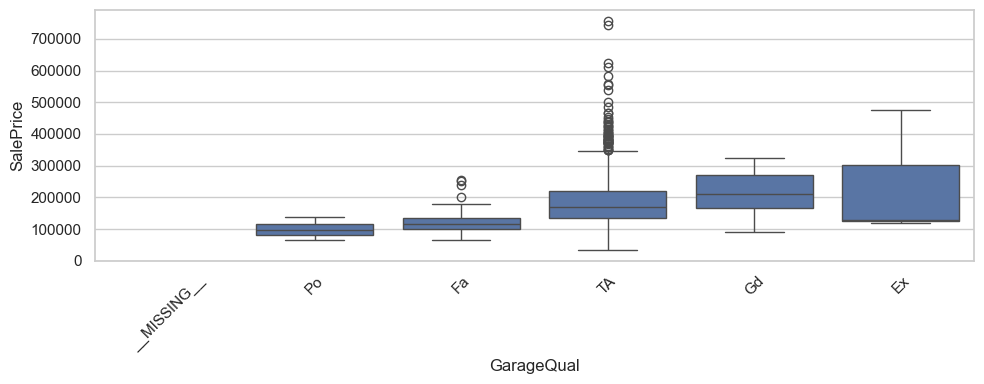

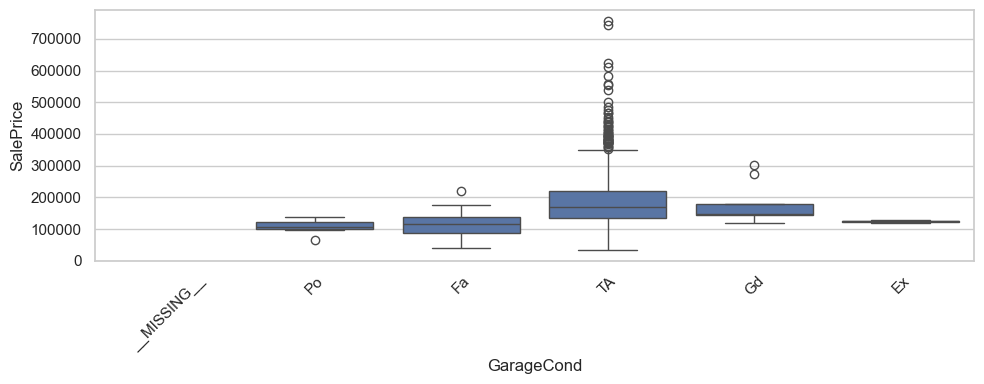

In [ ]:
for feature_name in [feature for feature in derived_features if "Garage" in feature]:
    inspect_numeric_feature(feature_name)
if "GarageQual" in ordinal_features:
    inspect_ordinal_feature("GarageQual")
if "GarageCond" in ordinal_features:
    inspect_ordinal_feature("GarageCond")
if "GarageArea" in train_augmented.columns:
    garage_zero_mask = train_augmented["GarageArea"] == 0
    display(compare_raw_vs_processed_rows(garage_zero_mask, feature_keyword="Garage"))

## 9. Metrics and importance for the selected variant

,model_name,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,random_forest,30343.149499,6199.018939,17828.099813,1634.266374,0.843555,0.078220
1,linear_regression,32514.591693,7726.124386,18084.068894,1111.550308,0.816752,0.108611
2,ridge,32529.051922,8213.143259,17870.364569,1044.511167,0.814804,0.117691
3,lasso,33268.596962,9185.652656,18145.272647,1300.882086,0.803707,0.135306


,feature,importance_mean,importance_std
0,TotalSF,43539.048898,2275.035371
1,GarageCars,8092.764549,642.123852
2,KitchenQual,6110.447598,1439.985806
3,ExterQual,2824.662007,691.801364
4,YearRemodAdd,2758.899961,595.040714
5,BsmtQual,1807.458907,130.003898
6,LotArea,1648.230558,297.145054
7,GarageArea,1485.941772,126.449519
8,HouseAge,1287.468123,189.191912
9,TotalBathrooms,1240.081903,193.219890


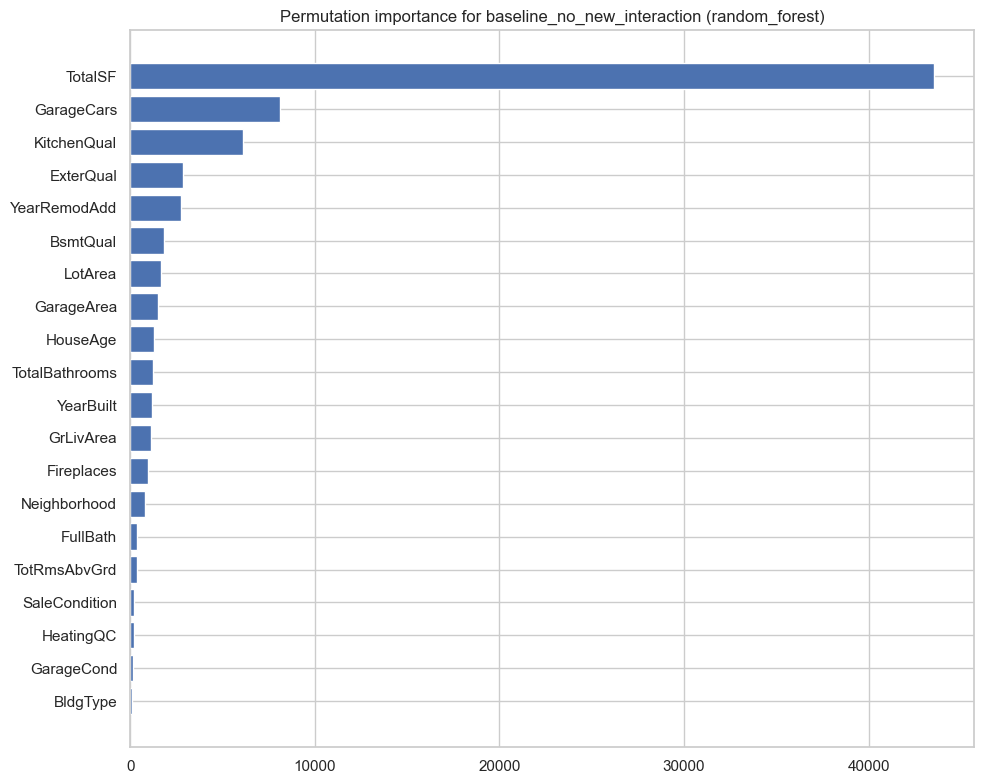

In [ ]:
selected_model_results = pd.DataFrame()
if RUN_MODEL_COMPARISON:
    selected_model_results = compare_models(MODEL_NAMES, X, y, selected_config)
    display(selected_model_results)
if RUN_PERMUTATION_IMPORTANCE:
    best_model_name = selected_model_results.iloc[0]["model_name"] if not selected_model_results.empty else PREVIEW_MODEL_NAME
    importance_df = compute_permutation_importance(best_model_name, X, y, selected_config, n_repeats=10)
    display(importance_df.head(20))
    plt.figure(figsize=(10, 8))
    plot_df = importance_df.head(20).sort_values("importance_mean")
    plt.barh(plot_df["feature"], plot_df["importance_mean"])
    plt.title(f"Permutation importance for {SELECTED_EXPERIMENT_KEY} ({best_model_name})")
    plt.tight_layout()

## 10. Optional save to outputs

In [ ]:
if SAVE_EXPERIMENT_OUTPUTS:
    save_config = replace(CONFIG, model_settings={model_name: CONFIG.model_settings[model_name] for model_name in MODEL_NAMES})
    saved_results = []
    for key, experiment in experiment_map.items():
        result = run_experiment(save_config, experiment)
        saved_results.append({
            "experiment_key": key,
            "best_model_name": result.get("best_model_name"),
            "experiment_dir": str(result.get("experiment_dir")),
        })
    display(pd.DataFrame(saved_results))
else:
    print("SAVE_EXPERIMENT_OUTPUTS is False. No files were written.")

SAVE_EXPERIMENT_OUTPUTS is False. No files were written.
